# QAOA and Intro to Quantum Machine Learning

## Lecture 8

### Last Time: Quantum Key Distirbution and the BB84 Protocol

### Other Topics You Have Seen: QFT, QPE, Shor, Grover, and QAE

### Today: Quantum Approximate Optimization Algorithms and QML
1. QAOA Workflow
2. Work through and simulate two examples
3. Discuss when QAOA is useful and what people use it for
4. An introduction to Quantum Machine Learning

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import itertools
import math

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=4, suppress=True)


def bit_value(bitstring, qubit):
    # Qiskit probability labels are printed with the highest-index qubit on the left.
    return int(bitstring[::-1][qubit])


def assignment_array(bitstring, n):
    return np.array([bit_value(bitstring, q) for q in range(n)], dtype=int)


def exact_probabilities(qc):
    return {str(k): float(v) for k, v in Statevector.from_instruction(qc).probabilities_dict().items()}


def expected_value(probabilities, cost_function):
    return float(sum(prob * cost_function(bitstring) for bitstring, prob in probabilities.items()))


def sample_counts(probabilities, shots=2000, seed=0):
    rng = np.random.default_rng(seed)
    labels = np.array(list(probabilities.keys()))
    probs = np.array(list(probabilities.values()), dtype=float)
    probs = probs / probs.sum()
    samples = rng.choice(labels, size=shots, p=probs)
    return {str(label): int(np.sum(samples == label)) for label in labels if np.sum(samples == label) > 0}


def top_bitstrings(probabilities, cost_function, k=8):
    rows = []
    for bitstring, prob in probabilities.items():
        rows.append((bitstring, prob, cost_function(bitstring)))
    return sorted(rows, key=lambda row: row[1], reverse=True)[:k]

# What Kind of Problem Is QAOA For?

A combinatorial optimization problem often looks like this:

$$\text{find } z\in\{0,1\}^n \text{ that maximizes } C(z).$$

The bit string $z$ describes a candidate solution.

Examples:

1. In MaxCut, $z_i$ says which side of the cut vertex $i$ belongs to.
2. In scheduling, $z_i$ may say whether job $i$ is assigned to a time slot.
3. In portfolio selection, $z_i$ may say whether asset $i$ is selected.
4. In satisfiability, $z_i$ may be the truth value of variable $i$.

QAOA tries to prepare a quantum state that gives high probability to good bit strings.

## From objective function to Hamiltonian

The main translation is:

$$C(z)\quad\longrightarrow\quad H_C.$$

We define a diagonal Hamiltonian by saying what it does to computational basis states:

$$H_C|z\rangle=C(z)|z\rangle.$$

So each basis state $|z\rangle$ is an eigenvector.

Its eigenvalue is the classical score $C(z)$.

If a quantum state is

$$|\psi\rangle=\sum_z a_z|z\rangle,$$

then the expected cost is

$$\langle H_C\rangle
=\langle\psi|H_C|\psi\rangle
=\sum_z |a_z|^2 C(z).$$

QAOA changes the amplitudes $a_z$ so that high-cost strings become more likely.

# The QAOA Ansatz

QAOA alternates two unitaries.

## The cost unitary

$$U_C(\gamma)=e^{-i\gamma H_C}.$$

Since $H_C|z\rangle=C(z)|z\rangle$,

$$U_C(\gamma)|z\rangle
=e^{-i\gamma C(z)}|z\rangle.$$

$U_C$ changes the relative phase of each computational basis state.

## The mixer unitary

$$U_B(\beta)=e^{-i\beta H_B}.$$

The standard mixer Hamiltonian is

$$H_B=\sum_{j=0}^{n-1}X_j.$$

At depth $p$, QAOA prepares

$$|\boldsymbol\gamma,\boldsymbol\beta\rangle
=U_B(\beta_p)U_C(\gamma_p)\cdots U_B(\beta_1)U_C(\gamma_1)|+\rangle^{\otimes n}.$$

## The mixer is just RX rotations

Because $X_i$ and $X_j$ commute for different qubits,

$$e^{-i\beta\sum_j X_j}=\prod_j e^{-i\beta X_j}.$$

Qiskit's rotation gate is

$$R_X(\theta)=e^{-i\theta X/2}.$$

Therefore

$$e^{-i\beta X}=R_X(2\beta).$$

So the standard mixer layer is simply:

$$R_X(2\beta)\text{ on every qubit}.$$

This mixer moves amplitude between bit strings.

## Hybrid optimization loop

QAOA is a hybrid quantum-classical algorithm.

1. Choose initial parameters $\boldsymbol\gamma,\boldsymbol\beta$.
2. Quantum computer prepares the QAOA state $|\boldsymbol\gamma,\boldsymbol\beta\rangle
=U_B(\beta_p)U_C(\gamma_p)\cdots U_B(\beta_1)U_C(\gamma_1)|+\rangle^{\otimes n}$.
3. Measure many bit strings.
4. Estimate the expected cost

$$F_p(\boldsymbol\gamma,\boldsymbol\beta)=\langle H_C\rangle.$$

5. Classical optimizer updates the parameters.
6. Repeat.

At the end, return either:

1. the best measured bit string, or
2. samples from the final probability distribution.

# QAOA Compared with Grover

- Grover has a binary good/bad oracle.
- QAOA has a graded objective $C(z)$.
- Grover amplifies marked states.
- QAOA biases probability toward high-scoring states using phases and mixing.

# Why MaxCut? A Concrete Example

Imagine we need to split people into two project teams A and B.

Each person has the ability to communicate with some subset of whole group. We want Team A and Team B to communicate efficiently with each other. How can you divide the whole group into two teams so that the number of lines of communication between the two teams A and B is maximized?

Represent each person as a vertex. Draw an edge between two people if we they have an existing line of communication. Now we have a graph.

The goal is:

> Split the vertices into two groups so that as many edges as possible go between the groups.

To solve this, we "cut" an edge whenever both of its vertices are on different teams. The total number of cuts is equal to the number of lines of communication between Team A and Team B. (The word "cut" here really means "count" -- we don't cut the line of communication, we just count it.)

## A small cut by hand

Suppose four vertices are connected by these edges:

$$E=\{(0,1),(1,2),(2,3),(3,0),(0,2)\}.$$

Try the split

$$A=\{0,2\},\qquad B=\{1,3\}.$$

Now check each edge:

| Edge | Crosses the split? |
|---:|:---:|
| $(0,1)$ | yes |
| $(1,2)$ | yes |
| $(2,3)$ | yes |
| $(3,0)$ | yes |
| $(0,2)$ | no |

So this split cuts/counts $4$ edges between Team A and Team B.

MaxCut asks for the split with the largest possible number of edges connecting the two groups A and B.

# MaxCut: Formal Definition

Take a graph $G=(V,E)$. For vertex $i$:

$$z_i=0\quad\text{means vertex }i\text{ is on team A},$$

$$z_i=1\quad\text{means vertex }i\text{ is on team B}.$$

An edge $(i,j)$ is cut exactly when its endpoints are on opposite sides: $z_i\ne z_j$.

For one edge $(i,j)$, define

$$C_{ij}(z)=\begin{cases}
1, & z_i\ne z_j,\\
0, & z_i=z_j.
\end{cases}$$

$z_i\oplus z_j=1$ when the edge is cut. So

$$C_{ij}(z)=z_i\oplus z_j.$$

Our goal is to maximize the total MaxCut objective function:

$$C(z)=\sum_{(i,j)\in E}(z_i\oplus z_j).$$

## Rewriting bits as Pauli Z eigenvalues

Computational basis states satisfy

$$Z|0\rangle=+|0\rangle,$$

$$Z|1\rangle=-|1\rangle.$$

For bit $z_i$, the corresponding $Z_i$ eigenvalue is

$$(-1)^{z_i}.$$

For two bits,

$$Z_iZ_j|z\rangle=(-1)^{z_i}(-1)^{z_j}|z\rangle=(-1)^{z_i+z_j}|z\rangle.$$

If $z_i=z_j$, this eigenvalue is $+1$.

If $z_i\ne z_j$, this eigenvalue is $-1$.

## MaxCut Hamiltonian

We want an operator with eigenvalue $1$ when the edge is cut and $0$ when it is not.

Use

$$H_{ij}=\frac{I-Z_iZ_j}{2}.$$

Check the two cases.

If $z_i=z_j$, then $Z_iZ_j$ has eigenvalue $+1$:

$$\frac{1-(+1)}{2}=0.$$

If $z_i\ne z_j$, then $Z_iZ_j$ has eigenvalue $-1$:

$$\frac{1-(-1)}{2}=1.$$

So the MaxCut cost Hamiltonian is

$$H_C=\sum_{(i,j)\in E}\frac{I-Z_iZ_j}{2}.$$

## MaxCut cost gates

For one edge,

$$U_{ij}(\gamma)=e^{-i\gamma(I-Z_iZ_j)/2}.$$

The $I$ part is a global phase:

$$e^{-i\gamma I/2},$$

which does not affect measurement probabilities.

The useful part is

$$e^{+i\gamma Z_iZ_j/2}.$$

Qiskit's two-qubit gate

$$R_{ZZ}(\theta)=e^{-i\theta Z_iZ_j/2}.$$

Therefore, with this sign convention,

$$U_{ij}(\gamma)\equiv R_{ZZ}(-\gamma)$$

up to a global phase.

# Example 1: MaxCut on a 4-Node Graph

We will use four vertices and five edges:

$$E=\{(0,1),(1,2),(2,3),(3,0),(0,2)\}.$$

This is a square plus one diagonal.

The maximum cut value is $4$.

There are two optimal cuts:

$$0101,\qquad 1010,$$

up to the qubit-labeling convention used in the code.

Best cut value: 4
Best cuts: ['0101', '1010']


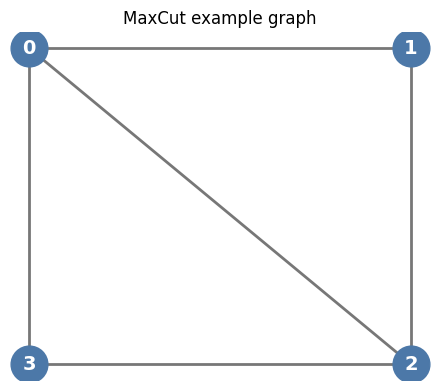

In [2]:
n_maxcut = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
positions = {
    0: np.array([0.0, 1.0]),
    1: np.array([1.0, 1.0]),
    2: np.array([1.0, 0.0]),
    3: np.array([0.0, 0.0]),
}


def draw_graph(edges, positions, title='Graph'):
    plt.figure(figsize=(4.5, 4))
    for i, j in edges:
        xs = [positions[i][0], positions[j][0]]
        ys = [positions[i][1], positions[j][1]]
        plt.plot(xs, ys, color='#777777', linewidth=2)
    for vertex, pos in positions.items():
        plt.scatter(pos[0], pos[1], s=700, color='#4c78a8', zorder=3)
        plt.text(pos[0], pos[1], str(vertex), color='white', ha='center', va='center', fontsize=14, weight='bold')
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()


def maxcut_value(bitstring, edges=edges):
    return int(sum(bit_value(bitstring, i) != bit_value(bitstring, j) for i, j in edges))

all_bitstrings = [format(z, f'0{n_maxcut}b') for z in range(2 ** n_maxcut)]
maxcut_scores = {z: maxcut_value(z) for z in all_bitstrings}
best_cut_value = max(maxcut_scores.values())
best_cuts = [z for z, score in maxcut_scores.items() if score == best_cut_value]

print('Best cut value:', best_cut_value)
print('Best cuts:', best_cuts)
draw_graph(edges, positions, title='MaxCut example graph')

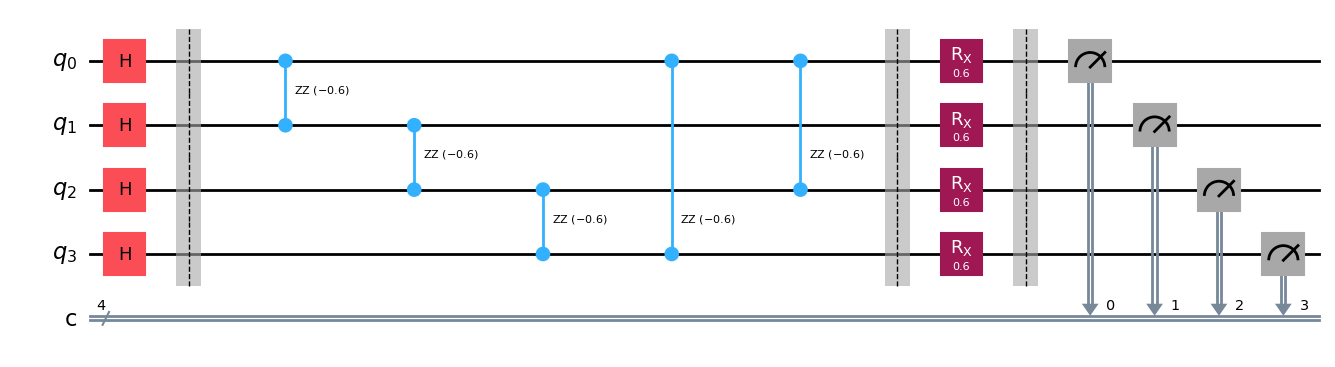

In [3]:
def qaoa_maxcut_circuit(n, edges, gammas, betas, measure=False):
    qc = QuantumCircuit(n, n if measure else 0)

    # Start in the uniform superposition |+>^n.
    qc.h(range(n))
    qc.barrier()

    for layer, (gamma, beta) in enumerate(zip(gammas, betas), start=1):
        # Cost layer: one RZZ per edge.
        for i, j in edges:
            qc.rzz(-gamma, i, j)
        qc.barrier()

        # Mixer layer: one RX per qubit.
        for q in range(n):
            qc.rx(2 * beta, q)
        qc.barrier()

    if measure:
        qc.measure(range(n), range(n))
    return qc

example_qc = qaoa_maxcut_circuit(n_maxcut, edges, gammas=[0.6], betas=[0.3], measure=True)
example_qc.draw(output='mpl')

## The objective landscape for $p=1$

For $p=1$, QAOA has only two parameters:

$$\gamma,\beta.$$

The expected cut value is

$$F_1(\gamma,\beta)=\langle\gamma,\beta|H_C|\gamma,\beta\rangle.$$

Since this example has only four qubits, we can compute this exactly from the statevector.

In real hardware, this expectation would be estimated from measurement shots.

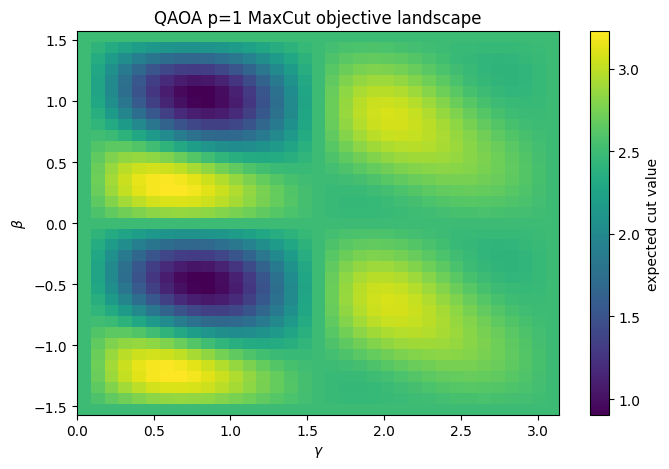

In [4]:
def qaoa_maxcut_expectation(params, p=1):
    gammas = params[:p]
    betas = params[p:]
    qc = qaoa_maxcut_circuit(n_maxcut, edges, gammas, betas, measure=False)
    probabilities = exact_probabilities(qc)
    return expected_value(probabilities, maxcut_value)

# Plot a p=1 landscape.
gamma_grid = np.linspace(0, np.pi, 35)
beta_grid = np.linspace(-np.pi / 2, np.pi / 2, 35)
landscape = np.zeros((len(beta_grid), len(gamma_grid)))

for bi, beta in enumerate(beta_grid):
    for gi, gamma in enumerate(gamma_grid):
        landscape[bi, gi] = qaoa_maxcut_expectation(np.array([gamma, beta]), p=1)

plt.figure(figsize=(7, 4.8))
plt.imshow(
    landscape,
    origin='lower',
    aspect='auto',
    extent=[gamma_grid[0], gamma_grid[-1], beta_grid[0], beta_grid[-1]],
    cmap='viridis',
)
plt.colorbar(label='expected cut value')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\beta$')
plt.title('QAOA p=1 MaxCut objective landscape')
plt.tight_layout()

In [5]:
def optimize_maxcut_p1():
    def objective(x):
        return -qaoa_maxcut_expectation(x, p=1)

    result = minimize(
        objective,
        x0=np.array([0.6, 0.3]),
        method='Nelder-Mead',
        options={'maxiter': 250},
    )
    return result

p1_result = optimize_maxcut_p1()
p1_gamma, p1_beta = p1_result.x
p1_expectation = -p1_result.fun

print('Optimized p=1 parameters:')
print('  gamma =', p1_gamma)
print('  beta  =', p1_beta)
print('Expected cut value =', p1_expectation)
print('Approximation ratio =', p1_expectation / best_cut_value)

Optimized p=1 parameters:
  gamma = 0.5713259198796004
  beta  = 0.3108519211853854
Expected cut value = 3.237108924593266
Approximation ratio = 0.8092772311483165


Most likely bitstrings after p=1 optimization:
0101: probability=0.1641, cut=4
1010: probability=0.1641, cut=4
0011: probability=0.0960, cut=3
0110: probability=0.0960, cut=3
1001: probability=0.0960, cut=3
1100: probability=0.0960, cut=3
0001: probability=0.0568, cut=3
1110: probability=0.0568, cut=3
0100: probability=0.0568, cut=3
1011: probability=0.0568, cut=3


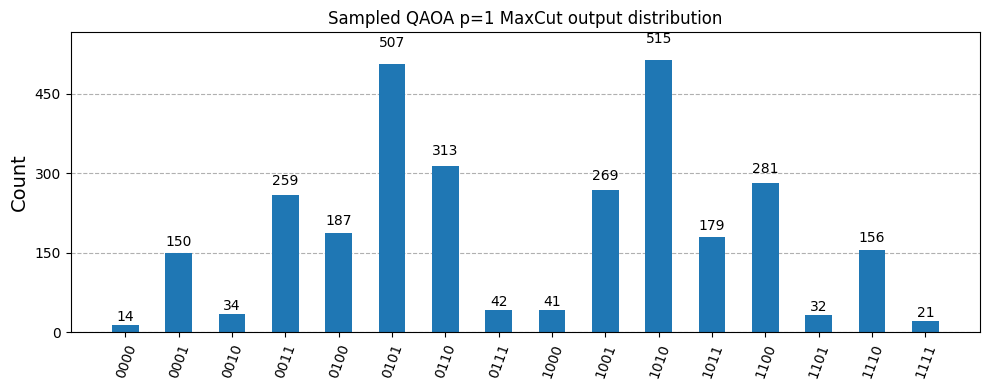

In [6]:
p1_qc = qaoa_maxcut_circuit(n_maxcut, edges, [p1_gamma], [p1_beta], measure=False)
p1_probabilities = exact_probabilities(p1_qc)
p1_counts = sample_counts(p1_probabilities, shots=3000, seed=9)

print('Most likely bitstrings after p=1 optimization:')
for bitstring, prob, score in top_bitstrings(p1_probabilities, maxcut_value, k=10):
    print(f'{bitstring}: probability={prob:.4f}, cut={score}')

plot_histogram(p1_counts, figsize=(10, 4), title='Sampled QAOA p=1 MaxCut output distribution')

## What the MaxCut simulation shows

The optimized $p=1$ QAOA state gives the largest probability to the optimal cuts.

For this graph, the optimal cut value is

$$C_{\max}=4.$$

The expected cut value after optimization is around

$$3.24,$$

so the expected approximation ratio is about

$$\frac{3.24}{4}\approx 0.81.$$

The measurement distribution is not deterministic.

QAOA is a sampling algorithm: good strings become more likely, not guaranteed.

## Increasing depth

At depth $p$, QAOA has $2p$ parameters:

$$\gamma_1,\ldots,\gamma_p,\beta_1,\ldots,\beta_p.$$

Larger $p$ gives a more expressive circuit family.

In the ideal global optimum, performance cannot get worse as $p$ increases, because a depth-$p$ circuit can imitate a lower-depth circuit by setting some layers to do nothing.

In practice, larger $p$ also means:

1. more gates,
2. more noise on hardware,
3. harder classical optimization.

In [7]:
def optimize_maxcut_p2():
    def objective(x):
        return -qaoa_maxcut_expectation(x, p=2)

    result = minimize(
        objective,
        x0=np.array([0.5, 1.1, 0.4, 0.2]),
        method='Nelder-Mead',
        options={'maxiter': 500},
    )
    return result

p2_result = optimize_maxcut_p2()
p2_params = p2_result.x
p2_expectation = -p2_result.fun

print('Optimized p=2 parameters:')
print('  gammas =', p2_params[:2])
print('  betas  =', p2_params[2:])
print('Expected cut value =', p2_expectation)
print('Approximation ratio =', p2_expectation / best_cut_value)

p2_probabilities = exact_probabilities(qaoa_maxcut_circuit(n_maxcut, edges, p2_params[:2], p2_params[2:]))
for bitstring, prob, score in top_bitstrings(p2_probabilities, maxcut_value, k=8):
    print(f'{bitstring}: probability={prob:.4f}, cut={score}')

Optimized p=2 parameters:
  gammas = [0.5168 1.1198]
  betas  = [0.3914 0.2003]
Expected cut value = 3.4572805419618042
Approximation ratio = 0.8643201354904511
0101: probability=0.2371, cut=4
1010: probability=0.2371, cut=4
0011: probability=0.0718, cut=3
1100: probability=0.0718, cut=3
0110: probability=0.0718, cut=3
1001: probability=0.0718, cut=3
0100: probability=0.0568, cut=3
1011: probability=0.0568, cut=3


# Example 2: Penalty QAOA for a Small Portfolio Toy Model

Suppose we have four possible projects/assets.

Let

$$z_i=1$$

mean we select item $i$.

The values are

$$v=(5,4,3,2).$$

We want to choose exactly two items and maximize total value.

The best feasible selection is items $0$ and $1$, with value

$$5+4=9.$$

This corresponds to the optimal bit string $z = z_3 z_2 z_1 z_0 = 0011$.

## Encoding a constraint as a penalty

The raw value of a bit string $z = z_3 z_2 z_1 z_0$ is

$$\sum_i v_i z_i.$$

Since we are only allowed to select two items, the constraint is

$$\sum_i z_i=2.$$

A common trick is to build an unconstrained objective with a penalty (c.f. Lagrange multipliers):

$$C(z)=\sum_i v_i z_i-\lambda\left(\sum_i z_i-2\right)^2.$$

Note that the QAOA circuit can visit invalid strings that select too many or two few items! However, if a bit string selects too many or too few items, the penalty lowers its score.

In [8]:
values = np.array([5, 4, 3, 2], dtype=float)
target_count = 2
penalty = 10.0 # lambda
n_portfolio = 4


def portfolio_score(bitstring):
    z = assignment_array(bitstring, n_portfolio)
    value = float(np.dot(values, z))
    violation = int(np.sum(z) - target_count)
    return value - penalty * violation ** 2

portfolio_bitstrings = [format(z, f'0{n_portfolio}b') for z in range(2 ** n_portfolio)]
portfolio_scores = {z: portfolio_score(z) for z in portfolio_bitstrings}
portfolio_best_score = max(portfolio_scores.values())
portfolio_best = [z for z, score in portfolio_scores.items() if score == portfolio_best_score]

print('Best penalized score:', portfolio_best_score)
print('Best bitstrings:', portfolio_best)
print('Scores by bitstring:')
for bitstring in portfolio_bitstrings:
    print(bitstring, portfolio_scores[bitstring])

Best penalized score: 9.0
Best bitstrings: ['0011']
Scores by bitstring:
0000 -40.0
0001 -5.0
0010 -6.0
0011 9.0
0100 -7.0
0101 8.0
0110 7.0
0111 2.0
1000 -8.0
1001 7.0
1010 6.0
1011 1.0
1100 5.0
1101 0.0
1110 -1.0
1111 -26.0


In [9]:
def qaoa_diagonal_cost_circuit(n, cost_values, gammas, betas, measure=False):
    qc = QuantumCircuit(n, n if measure else 0)
    qc.h(range(n))

    cost_values = np.asarray(cost_values, dtype=float)
    for gamma, beta in zip(gammas, betas):
        phases = np.exp(-1j * gamma * cost_values)
        qc.unitary(np.diag(phases), range(n), label=f'U_C')
        for q in range(n):
            qc.rx(2 * beta, q)

    if measure:
        qc.measure(range(n), range(n))
    return qc

portfolio_cost_values = [portfolio_score(format(z, f'0{n_portfolio}b')) for z in range(2 ** n_portfolio)]


def portfolio_expectation(params, p=2):
    gammas = params[:p]
    betas = params[p:]
    qc = qaoa_diagonal_cost_circuit(n_portfolio, portfolio_cost_values, gammas, betas)
    probabilities = exact_probabilities(qc)
    return expected_value(probabilities, portfolio_score)


def optimize_portfolio_p2():
    def objective(x):
        return -portfolio_expectation(x, p=2)

    result = differential_evolution(
        objective,
        bounds=[(0, np.pi), (0, np.pi), (-np.pi / 2, np.pi / 2), (-np.pi / 2, np.pi / 2)],
        seed=3,
        maxiter=30,
        polish=True,
    )
    return result

portfolio_result = optimize_portfolio_p2()
portfolio_params = portfolio_result.x
portfolio_expected = -portfolio_result.fun

print('Optimized portfolio p=2 parameters:')
print('  gammas =', portfolio_params[:2])
print('  betas  =', portfolio_params[2:])
print('Expected penalized score =', portfolio_expected)
print('Best possible penalized score =', portfolio_best_score)

Optimized portfolio p=2 parameters:
  gammas = [0.9101 0.8009]
  betas  = [ 1.0689 -0.1634]
Expected penalized score = 7.33130177365535
Best possible penalized score = 9.0


Most likely portfolio bitstrings:
0011: probability=0.4958, score=9.0, selected=[0, 1], feasible=True
0101: probability=0.1805, score=8.0, selected=[0, 2], feasible=True
1001: probability=0.0915, score=7.0, selected=[0, 3], feasible=True
0110: probability=0.0836, score=7.0, selected=[1, 2], feasible=True
0111: probability=0.0574, score=2.0, selected=[0, 1, 2], feasible=False
1010: probability=0.0347, score=6.0, selected=[1, 3], feasible=True
1100: probability=0.0157, score=5.0, selected=[2, 3], feasible=True
0001: probability=0.0128, score=-5.0, selected=[0], feasible=False
0010: probability=0.0083, score=-6.0, selected=[1], feasible=False
0100: probability=0.0060, score=-7.0, selected=[2], feasible=False


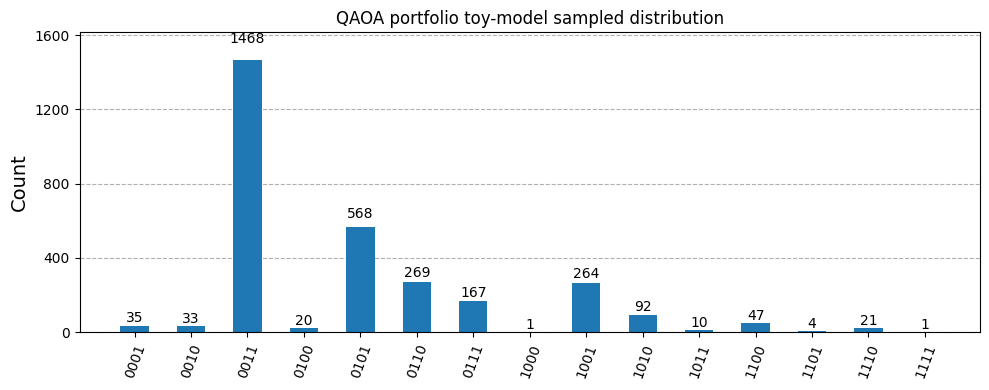

In [10]:
portfolio_qc = qaoa_diagonal_cost_circuit(
    n_portfolio,
    portfolio_cost_values,
    portfolio_params[:2],
    portfolio_params[2:],
)
portfolio_probabilities = exact_probabilities(portfolio_qc)
portfolio_counts = sample_counts(portfolio_probabilities, shots=3000, seed=22)

print('Most likely portfolio bitstrings:')
for bitstring, prob, score in top_bitstrings(portfolio_probabilities, portfolio_score, k=10):
    selected = [q for q in range(n_portfolio) if bit_value(bitstring, q) == 1]
    feasible = len(selected) == target_count
    print(f'{bitstring}: probability={prob:.4f}, score={score:.1f}, selected={selected}, feasible={feasible}')

plot_histogram(portfolio_counts, figsize=(10, 4), title='QAOA portfolio toy-model sampled distribution')

## What the portfolio example shows

The best feasible selection is items $0$ and $1$.

In this bit-labeling convention, that appears as

$$0011.$$

The optimized QAOA distribution gives this string the largest probability.

This example also shows a limitation of penalty methods:

The Hilbert space still contains invalid strings.

The penalty discourages them, but the standard mixer can still put nonzero amplitude there.

## Why QAOA can be useful

QAOA is most natural for
- Optimization problems on binary inputs
- Problems where the objective decomposes into a Hamiltonian composed of local terms
- Finding close-to-optimal states is more important than proving true optimality

## Local Terms

For MaxCut,

$$H_C=\sum_{(i,j)\in E}\frac{I-Z_iZ_j}{2}.$$

Each term only looks at two qubits. That is what we mean by **local terms**.

A $k$-local term acts on at most $k$ qubits, even if the full problem has many qubits. For example, $Z_1Z_2Z_7$ is 3-local.

Another example is a global constraint penalty:

$$\left(\sum_{i=0}^{n-1} z_i-k\right)^2.$$

When expanded, this particular penalty only creates one- and two-body terms.

Local terms are useful because they usually become short gates or small groups of gates.

A nonlocal term depends on many variables at once. More complicated global constraints can create high-order interactions that are expensive to implement directly. The more nonlocal the Hamiltonian is, the harder it usually is to compile into a shallow circuit.

## When could QAOA beat classical optimization?

A long-term advantage would likely require several things to be true at once:

1. The problem has exploitable structure that maps to a reasonably local Hamiltonian.
2. The best classical heuristics for that problem do not already exploit the same structure better.The QAOA circuit can be run at enough depth $p$ to create useful nonclassical correlations.
3. The classical optimizer can find good parameters without too many circuit calls.
4. The quantum device is large and reliable enough that noise does not erase the effect.

> For some structured hard instances, quantum sampling from an optimized alternating circuit MIGHT produce better candidates per unit resource than the best available classical heuristics.

## What problems do people try with QAOA?

Common application areas include graph problems, constraint satisfaction, scheduling/routing-style encodings, finance, spin glasses, and constrained optimization.

A few useful papers to look at:

1. Original QAOA paper, with MaxCut analysis: [Farhi, Goldstone, Gutmann, 2014](https://arxiv.org/abs/1411.4028)
2. Generalized mixers and constrained problems: [Hadfield et al., 2017](https://arxiv.org/abs/1709.03489)
3. Multi-objective optimization via Pareto-front finding: [Kotil et al., 2025] (https://doi.org/10.1038/s43588-025-00873-y)
3. Portfolio optimization with QAOA-style formulations: [Uotila, Ripatti, Zhao, 2025](https://arxiv.org/abs/2509.01496)
4. Cautionary portfolio benchmark against classical methods: [Stopfer and Wagner, 2025](https://arxiv.org/abs/2509.17876)
<!-- 6. Broad QAOA review: [Blekos et al., 2024](https://doi.org/10.1016/j.physrep.2024.03.002) -->

A lot of QAOA research asks:

> Can structured quantum sampling compete with or improve classical heuristics for useful optimization instances?

# Connection to Quantum Machine Learning

QAOA is a variational quantum algorithm.

Quantum machine learning often uses the same training pattern:

$$\text{choose parameters} \to \text{run quantum circuit} \to \text{measure objective} \to \text{classically update parameters}.$$

The difference is the objective.

In QAOA, we are trying to maximize an objective $C(z)$ that corresponds to a known Hamiltonian $H_C$. Equivalently, we are trying to minimize the expected value of the known Hamiltonian:

$$L(\theta)=-\langle H_C\rangle$$

In supervised QML, the objective comes from labeled data, and the Hamiltonian is not fully known.

## Classical supervised learning setup

A training set is

$$\mathcal D=\{(x_i,y_i)\}_{i=1}^N,$$

where

$$x_i\in\mathbb R^d$$

is a feature vector and $y_i$ is a label.

For binary classification, labels are often

$$y_i\in\{-1,+1\}.$$

A model is a parameterized function

$$f_\theta:\mathbb R^d\to\mathbb R.$$

A prediction might be

$$\hat y(x)=\operatorname{sign}(f_\theta(x)).$$

Training means choosing $\theta$ to minimize a loss, for example

$$L(\theta)=\frac1N\sum_{i=1}^N(f_\theta(x_i)-y_i)^2.$$

## Basic variational QML model

A common variational QML model has three pieces:

$$\text{encoding circuit}\quad\to\quad\text{trainable quantum circuit}\quad\to\quad\text{measurement}.$$

Given a classical input $x$, apply a data-encoding unitary:

$$|\phi(x)\rangle=U_\phi(x)|0\rangle^{\otimes n}.$$

Then apply a trainable circuit:

$$|\psi(x,\theta)\rangle=W(\theta)|\phi(x)\rangle.$$

Finally measure an observable $M$.

The model output is

$$f_\theta(x)=\langle\psi(x,\theta)|M|\psi(x,\theta)\rangle.$$

Equivalently,

$$f_\theta(x)=\langle0|U_\phi(x)^\dagger W(\theta)^\dagger M W(\theta)U_\phi(x)|0\rangle.$$

## Variational quantum classifier

For binary classification, choose an observable such as

$$M=Z_0.$$

Then

$$f_\theta(x)\in[-1,1].$$

If labels are

$$y\in\{-1,+1\},$$

we can train with squared loss:

$$L(\theta)=\frac1N\sum_{i=1}^N(f_\theta(x_i)-y_i)^2.$$

The quantum computer estimates each value

$$f_\theta(x_i).$$

The classical optimizer updates

$$\theta.$$

This is structurally similar to QAOA.

## Relationship to QAOA

QAOA prepares

$$|\boldsymbol\gamma,\boldsymbol\beta\rangle
=U_B(\beta_p)U_C(\gamma_p)\cdots U_B(\beta_1)U_C(\gamma_1)|s\rangle.$$

A variational quantum classifier prepares

$$|\psi(x,\theta)\rangle=W(\theta)U_\phi(x)|0\rangle.$$

They share the same training structure:

$$\text{parameters} \to \text{quantum circuit} \to \text{measurement} \to \text{classical update}.$$

The difference is the objective:

$$\text{QAOA: } L(\theta)=-\langle H_C\rangle,$$

$$\text{QML: } L(\theta)=\frac1N\sum_i\ell(f_\theta(x_i),y_i).$$

QAOA optimizes over bit strings. QML learns a function from data.

# Tiny Example: One-Qubit Classifier

We will train a one-qubit variational classifier.

Data encoding:

$$U_\phi(x)=R_Y(x).$$

There is nothing sacred about $R_Y(x)$. We choose it because it is the simplest angle encoding: one real feature $x$ becomes one rotation angle on the Bloch sphere.

Trainable circuit:

$$W(\theta)=R_Y(\theta).$$

Measurement:

$$M=Z.$$

So

$$f_\theta(x)=\langle Z\rangle.$$

The training data has two points labeled $+1$ near small angles and two points labeled $-1$ near large angles.

## Analytic Check

For this particular circuit, we can work out what the model should be without running Qiskit.

The circuit is

$$R_Y(\theta)R_Y(x)|0\rangle.$$

Rotations around the same axis add:

$$R_Y(\theta)R_Y(x)=R_Y(x+\theta).$$

Therefore the final state is

$$R_Y(x+\theta)|0\rangle
=\cos\left(\frac{x+\theta}{2}\right)|0\rangle
+\sin\left(\frac{x+\theta}{2}\right)|1\rangle.$$

Measuring $Z$ gives

$$f_\theta(x)=\langle Z\rangle
=\cos^2\left(\frac{x+\theta}{2}\right)-\sin^2\left(\frac{x+\theta}{2}\right)
=\cos(x+\theta).$$

So the graph should look like a cosine curve shifted by the learned parameter $\theta$.

The decision boundary is where

$$\cos(x+\theta)=0,$$

so roughly

$$x+\theta=\frac{\pi}{2}.$$

Learned theta = 0.020781250000000157
Training loss = 0.0237682917947444
x=0.20, label=+1, f_theta(x)=0.976, prediction=+1
x=0.65, label=+1, f_theta(x)=0.783, prediction=+1
x=2.45, label=-1, f_theta(x)=-0.783, prediction=-1
x=2.90, label=-1, f_theta(x)=-0.976, prediction=-1


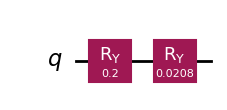

In [11]:
def qml_classifier_circuit(x, theta):
    qc = QuantumCircuit(1)
    qc.ry(x, 0)       # data encoding U_phi(x)
    qc.ry(theta, 0)   # trainable circuit W(theta)
    return qc


def z_expectation_one_qubit(qc):
    probabilities = Statevector.from_instruction(qc).probabilities_dict()
    p0 = float(probabilities.get('0', 0.0))
    p1 = float(probabilities.get('1', 0.0))
    return p0 - p1


def qml_model_output(x, theta):
    return z_expectation_one_qubit(qml_classifier_circuit(x, theta))


def qml_loss(theta, x_train, y_train):
    predictions = np.array([qml_model_output(x, theta[0]) for x in x_train])
    return float(np.mean((predictions - y_train) ** 2))

x_train = np.array([0.20, 0.65, 2.45, 2.90])
y_train = np.array([+1, +1, -1, -1])

qml_result = minimize(lambda theta: qml_loss(theta, x_train, y_train), x0=np.array([0.1]), method='Nelder-Mead')
theta_star = float(qml_result.x[0])
print('Learned theta =', theta_star)
print('Training loss =', qml_loss(np.array([theta_star]), x_train, y_train))

for x, y in zip(x_train, y_train):
    f = qml_model_output(x, theta_star)
    print(f'x={x:.2f}, label={y:+.0f}, f_theta(x)={f:.3f}, prediction={np.sign(f):+.0f}')

qml_classifier_circuit(x_train[0], theta_star).draw(output='mpl')

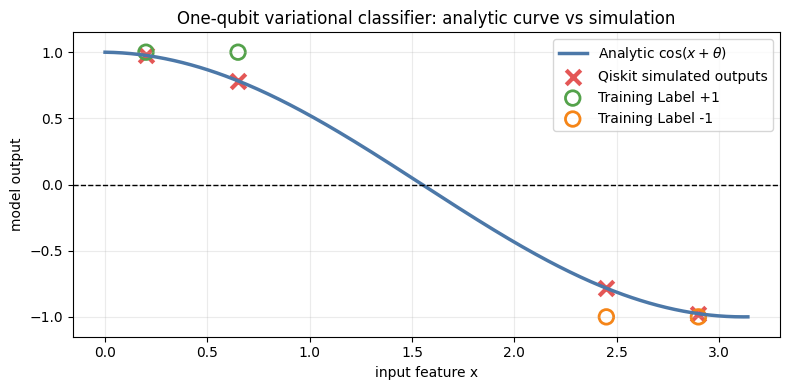

In [12]:
x_grid = np.linspace(0, np.pi, 300)
analytic_curve = np.cos(x_grid + theta_star)

# These are the values estimated by simulating the quantum circuit at the training inputs.
simulated_train_outputs = np.array([qml_model_output(x, theta_star) for x in x_train])

plt.figure(figsize=(8, 4))
plt.plot(
    x_grid,
    analytic_curve,
    color='#4c78a8',
    linewidth=2.5,
    label=r'Analytic $\cos(x+\theta)$',
)
plt.scatter(
    x_train,
    simulated_train_outputs,
    color='#e45756',
    marker='x',
    s=110,
    linewidths=3,
    label='Qiskit simulated outputs',
)
plt.scatter(
    x_train[y_train == 1],
    y_train[y_train == 1],
    facecolors='none',
    edgecolors='#54a24b',
    s=110,
    linewidths=2,
    label='Training Label +1',
)
plt.scatter(
    x_train[y_train == -1],
    y_train[y_train == -1],
    facecolors='none',
    edgecolors='#f58518',
    s=110,
    linewidths=2,
    label='Training Label -1',
)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('input feature x')
plt.ylabel('model output')
plt.title('One-qubit variational classifier: analytic curve vs simulation')
plt.ylim(-1.15, 1.15)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

# Takeaways

QAOA:
- It turns a classical objective into a diagonal Hamiltonian.
- The cost unitary gives basis states score-dependent phases. The mixer unitary turns those phases into amplitude differences.
- A classical optimizer searches for good angles. Larger depth circuits are more expressive, but also physically and computationally more expensive.
- At the end, we sample bit strings and keep high-scoring candidates.
- QAOA is one member of the broader family of variational quantum algorithms.


QML:
- In QAOA, the objective is usually a known Hamiltonian. In QML, the objective usually comes from labeled data.
- In QAOA, the circuit searches for high-scoring bit strings of a known optimization problem. In QML, the circuit is a trainable function approximator.
- QML follows a similar workflow to QAOA:
1. Choose parameters,
2. Run a quantum circuit,
3. Measure an expectation value of some observable (an operator),
4. Compute a classical loss,
5. Update the parameter.